## 2.1 The Model


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


#THE MODEL

params = {
    "N": 50000, #Individuals
    "p_e": (0.40, 0.35, 0.25), #short, medium, or long education probabilities
    "S_e": (1, 3, 5), #years of education for short, medium, or long education
    "h_e0": (1.00, 1.20, 1.55), #initial human capital for short, medium, or long education
    "delta_e": (0.010, 0.020, 0.030), #human capital growth while employed for short, medium, or long education
    "delta": 0.06, #human capital depreciation while unemployed
    "sigma_psi": 0.10, #standard deviation of log-normal distribution for individual productivity shocks
    "lambda": 0.60, #probability of finding job while unemployed
    "sigma": 0.05, #probability of losing job while employed
    "y_su": 0.45, #student grant while in education
    "rho": 0.60, #replacement rate for the unemployed
    "y_floor": 0.35, #minimum income for the unemployed
    "age_start": 18,
    "age_end": 65,
    "seed": 2025,
    "ability_threshold": (0.00, 0.20, 0.35), # For 2.5: minimum ability for short, medium, and long education
}

#Random number generator
rng = np.random.default_rng(params["seed"])

edu = rng.choice(len(params["p_e"]), size=params["N"], p=params["p_e"]) #Education of 0 = short, 1 = medium, 2 = long given probabilities p_e


def sim_model(
    params,
    no_education_differences=False, #For 2.4
    no_hc_shocks=False, #For 2.4
    no_unemployment_depreciation=False, #For 2.4
    no_unemployment=False, #For 2.4
    ability_demotion=False, #For 2.5
): 
    
    rng = np.random.default_rng(params["seed"])
    education = rng.choice(len(params["p_e"]), size=params["N"], p=params["p_e"])

    #For
    if no_education_differences:
        education = np.ones(params["N"], dtype=int)
        intended_education = education.copy()

    #For 2.5: Introduce effort/abilities as a threshold to graduate at intended education
    intended_education = education.copy()  #preserves intended education before possible demotion
    ability = np.full(params["N"], np.nan) 
    if ability_demotion: 
        #Separate RNG preserves all baseline employment and shock draws.
        ability_rng = np.random.default_rng(params["seed"] + 1)
        ability = ability_rng.uniform(0, 1, size=params["N"]) #effort/ability is in interval [0,1]
        thresholds = np.asarray(params["ability_threshold"])
        failed = ability < thresholds[intended_education]
        education[failed] = np.maximum(intended_education[failed] - 1, 0) 
        
    #Create arrays for the parameters that depend on education level
    S_e = np.array(params["S_e"])
    h_e0 = np.array(params["h_e0"])
    delta_e = np.array(params["delta_e"])

    S_e_person = S_e[education] #years of education for each individual
    h_e0_person = h_e0[education] #initial human capital for each individual
    delta_e_person = delta_e[education] #human capital growth while employed for each individual


    #Initial states
    employed = np.zeros(params["N"], dtype=bool)
    active = np.zeros(params["N"], dtype=bool)
    human_capital = np.zeros(params["N"], dtype=float)
    income = np.full(params["N"], params["y_su"], dtype=float)
    last_job_income = np.zeros(params["N"], dtype=float)
    yearly_results = []

    for age in range(params["age_start"],params["age_end"]+1):
        years_since_start = age - params["age_start"]

        still_in_edu = years_since_start < S_e_person
        just_graduated = years_since_start == S_e_person

        #Graduates enter the labour force unemployed
        active[just_graduated] = True
        employed[just_graduated] = no_unemployment
        human_capital[just_graduated] = h_e0_person[just_graduated]

        previously_employed = employed.copy()

        #Probability of individual finding and loosing job
        job_find = rng.binomial(
            n=1,
            p=params["lambda"],
            size=params["N"]
        ).astype(bool)

        job_loss = rng.binomial(
            n=1,
            p=params["sigma"],
            size=params["N"]
        ).astype(bool)
        
        #Outcomes for active individuals
        newly_unemployed = (active & previously_employed & job_loss)

        newly_employed = (active & ~previously_employed & job_find)

        #Updated employment status
        if not no_unemployment:
            employed[newly_unemployed] = False
            employed[newly_employed] = True

        #Individual human capital shock
        psi_t = rng.lognormal(-0.5 * params["sigma_psi"] ** 2, params["sigma_psi"], size=params["N"])
        if no_hc_shocks:
            psi_t = np.ones(params["N"])

        #Updated human capital
        hc_employed = human_capital * (1 + delta_e_person) * psi_t
        unemployment_growth = 1 if no_unemployment_depreciation else 1 - params["delta"]
        hc_unemployed = human_capital * unemployment_growth * psi_t

        new_hc = np.where(
            employed,
            hc_employed,
            hc_unemployed
        )

        human_capital = np.where(
            active,
            new_hc,
            human_capital
        )

        #Income depends on the individual's human capital and employment in the current year.
        employed_income = human_capital
        last_job_income[employed] = employed_income[employed]

        unemployed_income = np.maximum(
            params["rho"] * last_job_income,
            params["y_floor"]
        )

        income = np.where(
            still_in_edu,
            params["y_su"],
            np.where(
                employed,
                employed_income,
                unemployed_income
            )
        )

        yearly_results.append(
            pd.DataFrame({
                "id": np.arange(params["N"]),
                "age": age,
                "education": education,
                "intended_education": intended_education, #For 2.5
                "ability": ability, #For 2.5
                "income": income.copy(),
                "human_capital": human_capital.copy(),
                "employed": employed.copy(),
                "active": active.copy(),
            })
        )

    results = pd.concat(yearly_results, ignore_index=True)

    return results


#Run the simulation once before checking and plotting the results
results = sim_model(params)




## 2.2 

2.2.1 Model Simulation Check

In [20]:

#Human capital shock mean
psi_t = rng.lognormal(-0.5 * params["sigma_psi"] ** 2, params["sigma_psi"], size=params["N"])

print("Target human capital shock mean:", 1)
print("Simulated human capital shock mean:", psi_t.mean())

#Simulated education shares mirror target
print("Target education shares:", params["p_e"])
print("Simulated education shares:", np.bincount(edu) / params["N"])

#Simulated unemployment steady state mirror theory
theoretical_unemployment = params["sigma"] / (params["sigma"] + params["lambda"])

active_results = results.loc[results["active"]].copy()

unemployment_by_age = (
    active_results.assign(
        unemployed=~active_results["employed"]
    )
    .groupby("age")["unemployed"]
    .mean()
)

#Use unemployment at age 65 as the simulated steady-state 
simulated_steady_state = unemployment_by_age.loc[65]


print("Theoretical steady-state unemployment rate:", theoretical_unemployment)
print(f"Simulated steady-state unemployment: {simulated_steady_state:.3f}")



Target human capital shock mean: 1
Simulated human capital shock mean: 0.9986132833247616
Target education shares: (0.4, 0.35, 0.25)
Simulated education shares: [0.40404 0.35026 0.2457 ]
Theoretical steady-state unemployment rate: 0.07692307692307693
Simulated steady-state unemployment: 0.078


The simulated results closely resemble the theoretical, meaning that the simulation is seemingly correct

2.2.2 Mean and percentiles of income over the life cycle plot

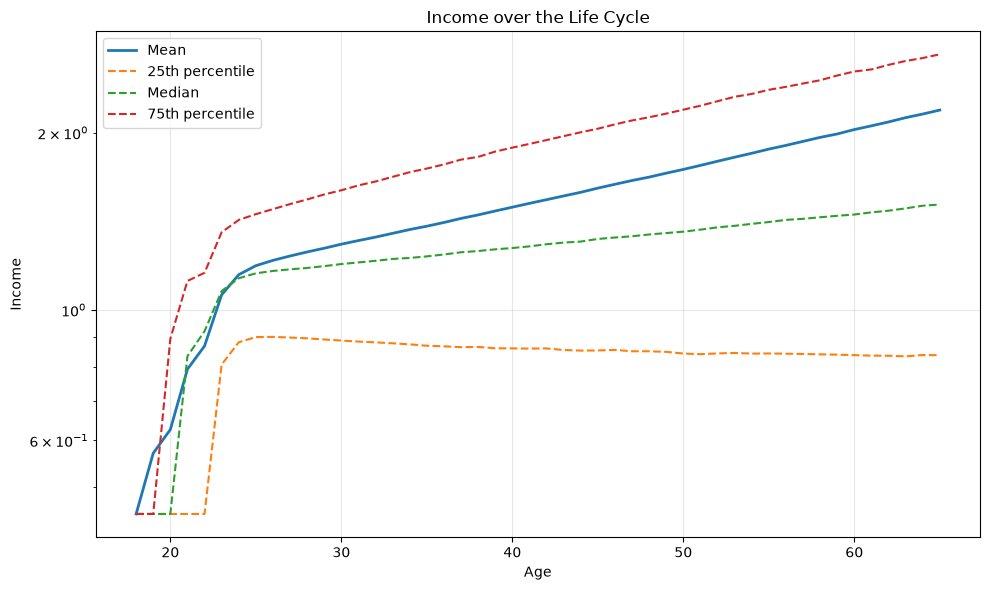

In [21]:
#Calculate income statistics for everyone at each age
income_stats = (
    results.groupby("age")["income"]
    .agg(
        mean="mean",
        p25=lambda x: x.quantile(0.25),
        median="median",
        p75=lambda x: x.quantile(0.75)
    )
    .reset_index()
)

# Plot
plt.figure(figsize=(10, 6))

plt.plot(income_stats["age"], income_stats["mean"], label="Mean", linewidth=2)

plt.plot(income_stats["age"], income_stats["p25"], label="25th percentile", linestyle="--")

plt.plot(income_stats["age"], income_stats["median"], label="Median", linestyle="--")

plt.plot(income_stats["age"], income_stats["p75"], label="75th percentile", linestyle="--")

plt.xlabel("Age")
plt.ylabel("Income")
plt.title("Income over the Life Cycle")
plt.yscale("log")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

When looking at the income over a life cycle, there is stark growth in the average income as the individuals start education and then graduate gradually. After this, the average income increases linearly, except for yearly small shocks in human capital. The 25^th percentile starts decreasing, while the median increases slightly, and the 75^th percentile and mean increase at a higher rate, with about the same amount.
The mean is higher than the median, which will be reflected in the histograms as a right-skewed distribution.

2.2.3 The income distribution at ages 25, 35, 45, and 60 histogram 

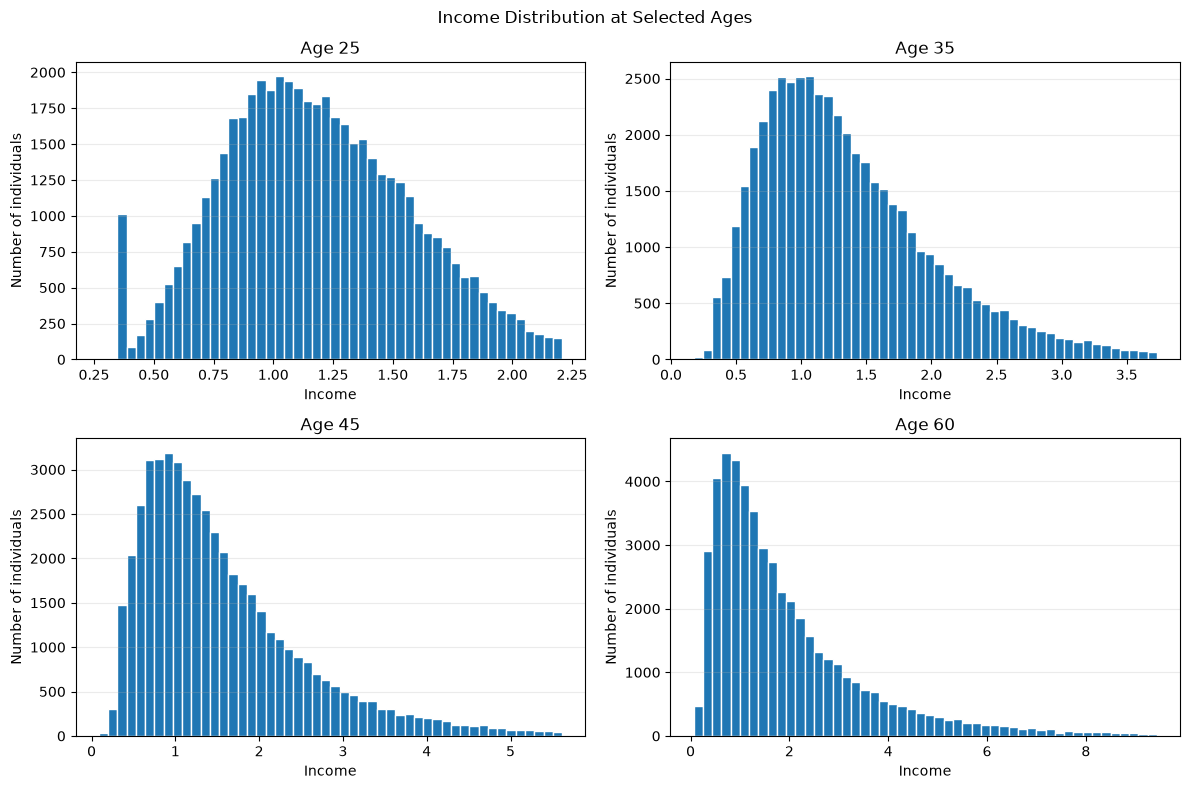

In [22]:
#Create four subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

#Ages to include
selected_ages = [25, 35, 45, 60]

for ax, age in zip(axes.flatten(), selected_ages):
    income_at_age = results.loc[
        results["age"] == age,
        "income"
    ]

    # Omit the highest 1% so the main distribution remains visible
    upper_limit = income_at_age.quantile(0.99)
    income_to_plot = income_at_age[
        income_at_age <= upper_limit
    ]

    ax.hist(
        income_to_plot,
        bins=50,
        edgecolor="white"
    )

    ax.set_title(f"Age {age}")
    ax.set_xlabel("Income")
    ax.set_ylabel("Number of individuals")
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Income Distribution at Selected Ages")
fig.tight_layout()
plt.show()

At age 25, the distribution is the closest to a normal distribution, with the expection of the individuals still earning their student grant salary, as they have just finished their studies, yet did not become employed. As individuals get older, the distribution becomes more and more right skewed, as to be expected, since the mean income grows faster than the median. 

This is due to a small group of individuals that excell, due to compounded human capital, and hence, achieve a significantly increased income over their work life cycle, rather than the general public having a decreasing income. This is evident by the mean continueing to be approximately 1.  


## 2.3 Gini coefficient and Lorenz curve


Uniform test:  simulated = 0.3333, theoretical = 0.3333
Lognormal test: simulated = 0.4271, theoretical = 0.4284

Pooled Gini: 0.3740
Mean within-age Gini: 0.3165
Minimum within-age Gini: 0.0000 at age 18
Maximum within-age Gini: 0.4561 at age 65
Age groups below pooled Gini: 32 of 48


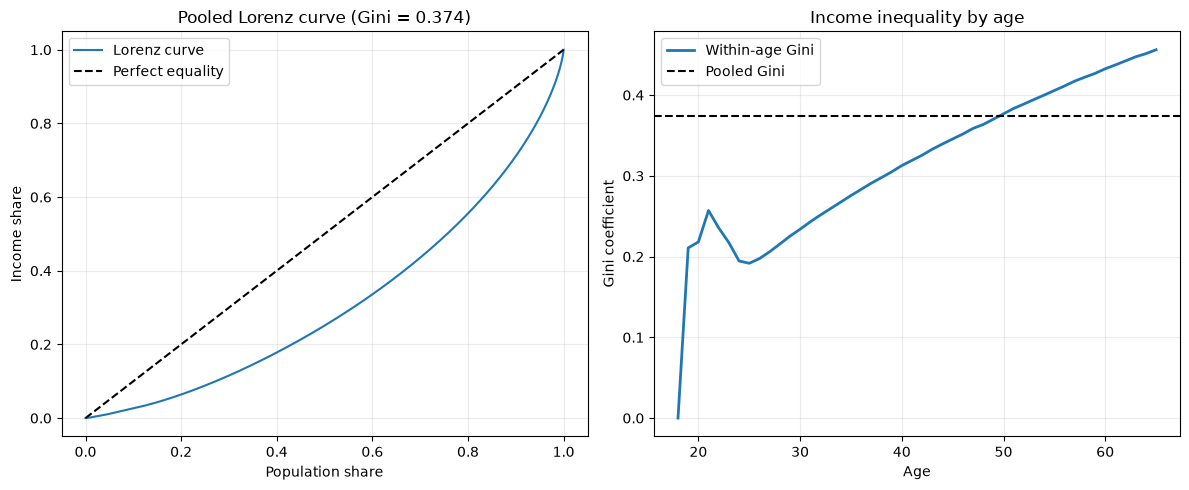

In [23]:
from math import erf, sqrt

#Gini-coefficient

def gini_coefficient(incomes):
    #Convert input into a vector 
    incomes = np.asarray(incomes, dtype=float).ravel()

    #Ensure that data is analyzable for gini-coefficient calculations
    if incomes.size == 0:
        raise ValueError("The income vector cannot be empty.") 
    if not np.all(np.isfinite(incomes)):
        raise ValueError("All incomes must be finite.")
    if np.any(incomes < 0):
        raise ValueError("This Gini implementation requires nonnegative incomes.")
    if np.all(incomes == 0):
        return 0.0

    #Sort income
    sorted_incomes = np.sort(incomes)
    n = sorted_incomes.size 
    ranks = np.arange(1, n + 1)

    #Sorted-income Gini formula
    return (
        np.sum((2 * ranks - n - 1) * sorted_incomes)
        / (n * sorted_incomes.sum())
    )


#Test uniform distribution on [0, 1], theoretical Gini = 1/3
uniform_sample = np.linspace(0, 1, params["N"])
uniform_gini = gini_coefficient(uniform_sample)

#Test lognormal distribution, theoretical Gini = 2*Phi(s/sqrt(2)) - 1
test_rng = np.random.default_rng(params["seed"])
s = 0.8 #standard deviation
lognormal_sample = test_rng.lognormal(mean=0, sigma=s, size=params["N"])
normal_cdf = lambda z: 0.5 * (1 + erf(z / sqrt(2))) #erf is error function for normal CDF
lognormal_theoretical_gini = 2 * normal_cdf(s / sqrt(2)) - 1
lognormal_simulated_gini = gini_coefficient(lognormal_sample)

#Ensures the simulated calculations are within specific deviation 
assert np.isclose(uniform_gini, 1 / 3, atol=1e-3) 
assert np.isclose(lognormal_simulated_gini, lognormal_theoretical_gini, atol=3e-3) #larger deviation allowance due to random sample

print(f"Uniform test:  simulated = {uniform_gini:.4f}, theoretical = {1/3:.4f}")
print(f"Lognormal test: simulated = {lognormal_simulated_gini:.4f}, theoretical = {lognormal_theoretical_gini:.4f}")

#Gini for all simulated person-year incomes and separately for each age
pooled_gini = gini_coefficient(results["income"]) #every person-year observation as part of one income distribution
gini_by_age = results.groupby("age")["income"].apply(gini_coefficient) #gini for compare individuals who are the same age


print(f"\nPooled Gini: {pooled_gini:.4f}")
print(f"Mean within-age Gini: {gini_by_age.mean():.4f}")
print(f"Minimum within-age Gini: {gini_by_age.min():.4f} at age {gini_by_age.idxmin()}")
print(f"Maximum within-age Gini: {gini_by_age.max():.4f} at age {gini_by_age.idxmax()}")
print(f"Age groups below pooled Gini: {(gini_by_age < pooled_gini).sum()} of {len(gini_by_age)}")





#Lorenz curve

def lorenz_curve(incomes):
    #Sorts data to create lorenz curve
    sorted_incomes = np.sort(np.asarray(incomes, dtype=float))
    cumulative_income = np.concatenate(([0.0], np.cumsum(sorted_incomes))) #np.concatenate adds zero to sorted accumulation
    cumulative_income /= cumulative_income[-1] #Cumulative share
    population_share = np.linspace(0, 1, sorted_incomes.size + 1) #Population share given as [0,1]
    return population_share, cumulative_income


population_share, income_share = lorenz_curve(results["income"])

#Downsample only the displayed curve; the Gini above uses every observation.
display_index = np.linspace(0, len(population_share) - 1, 2000, dtype=int) #2000 evenly spaced points

#Create plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(population_share[display_index], income_share[display_index], label="Lorenz curve")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="black", label="Perfect equality")
axes[0].set(title=f"Pooled Lorenz curve (Gini = {pooled_gini:.3f})", xlabel="Population share", ylabel="Income share")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(gini_by_age.index, gini_by_age.values, linewidth=2, label="Within-age Gini")
axes[1].axhline(pooled_gini, linestyle="--", color="black", label="Pooled Gini")
axes[1].set(title="Income inequality by age", xlabel="Age", ylabel="Gini coefficient")
axes[1].legend()
axes[1].grid(alpha=0.25)

fig.tight_layout()
plt.show()

The first graph show how the pooled lorenz curve. It can be seen that the 50% of the population that are the poorest only only have about 30% of the total income share. The second graph shows how the age-specific gini-coefficients compare to the overall. It can be seen that at 18, when no one has graduated, there is no within-age income inequality, as everyone recieves the same student grant. Then the inequality becomes starker as individuals graduate at different times. When everyone has graduated, the inequality rises with a slightly diminished marginal return. The inequality amongst within year individuals are higher than the general ginicoefficient after around 50 years of age.

## 2.4 Inequality

Compare the baseline with one model component switched off at a time


In [6]:
comparison_age = 45 #Used as a representative mid-career age, as everyone has graduated and experienced changes in employment status, human capital shocks, while not yet having results that are dominated by long accumulation

counterfactuals = {
    "Baseline": {},
    "No educational differences": {"no_education_differences": True},
    "No human-capital shocks": {"no_hc_shocks": True},
    "No unemployment depreciation": {"no_unemployment_depreciation": True},
    "No unemployment": {"no_unemployment": True},
}

gini_comparison = []

for simulation_name, switches in counterfactuals.items():
    #Reuse the baseline and hold the random seed fixed across alternatives.
    simulation_results = results if simulation_name == "Baseline" else sim_model(params, **switches)

    pooled = gini_coefficient(simulation_results["income"])
    within_age = gini_coefficient(
        simulation_results.loc[simulation_results["age"] == comparison_age, "income"]
    )

    gini_comparison.append({
        "simulation": simulation_name,
        "pooled_gini": pooled,
        f"gini_age_{comparison_age}": within_age,
    })

gini_comparison = pd.DataFrame(gini_comparison)
baseline_pooled = gini_comparison.loc[0, "pooled_gini"]
baseline_age = gini_comparison.loc[0, f"gini_age_{comparison_age}"]

gini_comparison["change_pooled"] = gini_comparison["pooled_gini"] - baseline_pooled
gini_comparison[f"change_age_{comparison_age}"] = (
    gini_comparison[f"gini_age_{comparison_age}"] - baseline_age
)
gini_comparison["percent_change_pooled"] = 100 * gini_comparison["change_pooled"] / baseline_pooled
gini_comparison[f"percent_change_age_{comparison_age}"] = (
    100 * gini_comparison[f"change_age_{comparison_age}"] / baseline_age
)

alternatives = gini_comparison.iloc[1:]
largest_pooled = alternatives.loc[alternatives["change_pooled"].abs().idxmax(), "simulation"]
largest_within_age = alternatives.loc[
    alternatives[f"change_age_{comparison_age}"].abs().idxmax(), "simulation"
]

display(gini_comparison.round(4))
print(f"Largest pooled effect: {largest_pooled}")
print(f"Largest effect at age {comparison_age}: {largest_within_age}")

,simulation,pooled_gini,gini_age_45,change_pooled,change_age_45,percent_change_pooled,percent_change_age_45
0,Baseline,0.3740,0.3457,0.0000,0.0000,0.0000,0.0000
1,No educational differences,0.3284,0.2961,-0.0457,-0.0496,-12.2081,-14.3460
2,No human-capital shocks,0.2723,0.2192,-0.1017,-0.1265,-27.1936,-36.5994
3,No unemployment depreciation,0.3789,0.3343,0.0049,-0.0114,1.3003,-3.2860
4,No unemployment,0.3776,0.3320,0.0036,-0.0137,0.9651,-3.9550


Largest pooled effect: No human-capital shocks
Largest effect at age 45: No human-capital shocks


We see that there are to factors that make the inequality larger, both in general and within ages: Educational differences and human capital shocks, with the latter having the most negative impact on equality. 

In contrast unemployment depreciation and unemployment do not increase inequality in general, with the former resulting in almost no change. However, at the age of 45 (mid career age, therefore not close to retiring), this is not the case. The removal of these two negative effects on income results in a lower gini at age 45, by removing the mechanism that seperates within age peers. The pooled gini coefficient rises in the alternative simulations as human capital growth compounds, and people with higher human capital do not get setbacks from either unemployment or depreciation from it. This means that the gain from a large human capital is higher than the loss effects from unemployment.

We find two factors that increase inequality, both in the pooled distribution and within age groups: educational differences and human capital shocks, with the shocks having the larger effect.

Removing unemployment, and the depreciation of human capital while unemployed, has different results. It  does not lower pooled inequality, instead pooled Gini rises in both alternative simulations relative to the baseline. At age 45 (mid-career), however, the opposite holds: removing either mechanism lowers the Gini coefficient within that age group.

This is due to unemployment affecting inequality in multiple ways. Within the same age group, unemployment interrupts the growth of human capital, and depreciation compounds this further. Over a career, small random differences in employment histories accumulate into meaningfully different human capital levels within same-aged peers. Removing unemployment or its depreciation eliminates this, so people of the same agelook more similar to one another. However, between ages we see that unemployment can periodically interrupt the human capital accumulation, halting the older indiciduals. Removing unemployment (or its depreciation) allows human capital to accumulate freely over the full work life-cycle, so the oldest individuals end up considerably richer than younger ones. This stretches the life-cycle income profile. In other words, the gain in inequality from unrestrained human capital compounding across the life cycle outweighs the reduction in inequality from removing the "setbacks" caused by unemployment and its depreciation.

## 2.5 Extension: Effort/abilities

We extend the model by introducing a variable, that affects the ability to graduate, and hence, future income. In this extended model, a variable for the effort/abilities of an individual is included. This variable is uniformly distributed (~U(0,1)) This variable determines if individuals can complete their years of education. If not, they fall back to the next highest amount of education years. For simplification, we assume that every individual has the effort/abilities to complete one year of education. 

Education shares before and after the ability rule:


,education,intended_share,realized_share,change
0,Short,0.4040,0.4745,0.0705
1,Medium,0.3503,0.3652,0.0149
2,Long,0.2457,0.1603,-0.0854


Overall demotion rate: 0.1559

Income distribution and inequality comparison:


,mean_income,p10_income,p25_income,median_income,p75_income,p90_income,pooled_gini,gini_age_45
Baseline,1.5145,0.45,0.7822,1.1898,1.8101,2.7983,0.3740,0.3457
Ability extension,1.4146,0.45,0.7550,1.1286,1.6851,2.5702,0.3617,0.3411
Absolute change,-0.0999,0.00,-0.0272,-0.0612,-0.1250,-0.2281,-0.0123,-0.0045
Percent change,-6.5958,0.00,-3.4768,-5.1441,-6.9066,-8.1508,-3.2858,-1.3078


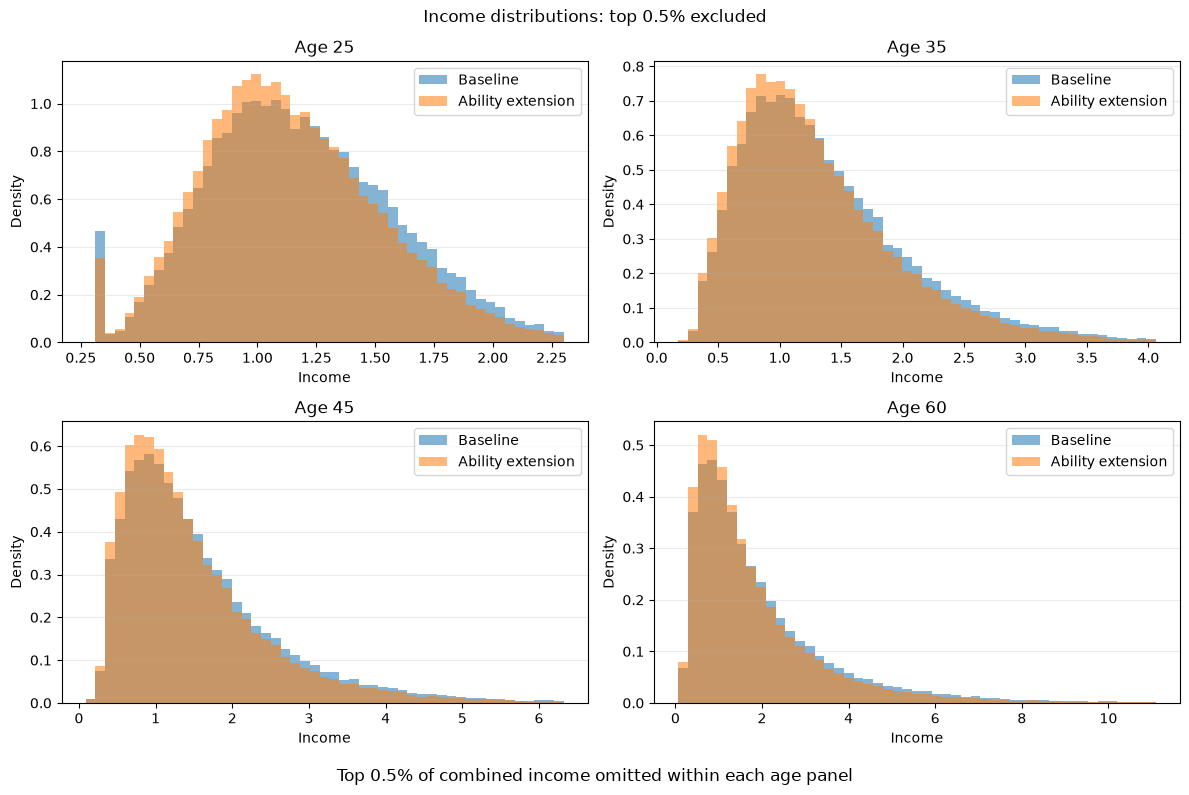

In [ ]:
#Remove temporary counterfactual from section 2.4 
if "simulation_results" in globals():
    del simulation_results

extended_results = sim_model(params, ability_demotion=True)
comparison_age = 45

#Ensure each individual appears once at every age
education_names = ["Short", "Medium", "Long"]
baseline_first_age = results.loc[results["age"] == params["age_start"]]
extended_first_age = extended_results.loc[extended_results["age"] == params["age_start"]]

#Create change in graduation results based on effort/ability
intended_shares = (
    extended_first_age["intended_education"].value_counts(normalize=True).sort_index()
)

realized_shares = (
    extended_first_age["education"].value_counts(normalize=True).sort_index()
)

#Create comparison table
education_comparison = pd.DataFrame({
    "education": education_names,
    "intended_share": intended_shares.reindex(range(3), fill_value=0).to_numpy(),
    "realized_share": realized_shares.reindex(range(3), fill_value=0).to_numpy(),
})

education_comparison["change"] = (
    education_comparison["realized_share"] - education_comparison["intended_share"]
)

demotion_rate = (
    extended_first_age["education"] < extended_first_age["intended_education"]
).mean()

print("Education shares before and after the ability rule:")
display(education_comparison.round(4))
print(f"Overall demotion rate: {demotion_rate:.4f}")

#Create plots and histograms
def income_and_gini_summary(sample):
    incomes = sample["income"]
    age_incomes = sample.loc[sample["age"] == comparison_age, "income"]
    return pd.Series({
        "mean_income": incomes.mean(),
        "p10_income": incomes.quantile(0.10),
        "p25_income": incomes.quantile(0.25),
        "median_income": incomes.median(),
        "p75_income": incomes.quantile(0.75),
        "p90_income": incomes.quantile(0.90),
        "pooled_gini": gini_coefficient(incomes),
        f"gini_age_{comparison_age}": gini_coefficient(age_incomes),
    })


baseline_summary = income_and_gini_summary(results)
extended_summary = income_and_gini_summary(extended_results)
absolute_change = extended_summary - baseline_summary
percent_change = 100 * absolute_change / baseline_summary

extension_comparison = pd.DataFrame({
    "Baseline": baseline_summary,
    "Ability extension": extended_summary,
    "Absolute change": absolute_change,
    "Percent change": percent_change,
}).T

print("\nIncome distribution and inequality comparison:")
display(extension_comparison.round(4))

#Compare baseline and extended income distributions at selected ages.
selected_ages = [25, 35, 45, 60]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, age in zip(axes.flat, selected_ages):
    baseline_income = results.loc[results["age"] == age, "income"]
    extended_income = extended_results.loc[extended_results["age"] == age, "income"]
    combined_income = pd.concat([baseline_income, extended_income], ignore_index=True)

    upper_limit = combined_income.quantile(0.995)
    bins = np.linspace(combined_income.min(), upper_limit, 50)

    ax.hist(
        baseline_income[baseline_income <= upper_limit],
        bins=bins,
        alpha=0.55,
        density=True,
        label="Baseline",
    )
    ax.hist(
        extended_income[extended_income <= upper_limit],
        bins=bins,
        alpha=0.55,
        density=True,
        label="Ability extension",
    )
    ax.set(title=f"Age {age}", xlabel="Income", ylabel="Density")
    ax.grid(axis="y", alpha=0.25)
    ax.legend()

fig.suptitle("Income distributions: top 0.5% excluded")
fig.tight_layout()
plt.show()


Introducing an effort/ability shock to education increases inequality. This adds a new barrier to human capital accumulation, which was already shown to have the largest effect on inequality in the baseline comparisons. Most individuals still complete their "assigned" education, but a subset now does not. Practically, effort/abilities represent whether or not an individual passes or fails. Therefore, this introduces another dynamic, where two individuals could be projected to have a similar life-cycle income, but due to personal differences, will achieve the same outcome. The mechanism is similar 

Notably, more individuals originally assigned to a 5-year education fail to complete it than those assigned to a 3-year education, which is reflected in the realized share of individuals with 3-year education increasing relative to its assigned share. 
Since this shock mostly reduces the number of individuals who successfully complete a 5-year education, the histograms show that it is primarily the mass of individuals earning close to the average salary that increases, while the mass in the highest income range shrinks. This means that the histograms become more right skewed.